In [ ]:
from backend_langgraph.search import search_and_crawl
from backend_langgraph.db import get_vectorstore, get_relevant_context, add_to_vector_database, has_relevant_data
from backend_langgraph.llm import call_llm
from backend_langgraph.util import few_shot_needs_web_search, is_website_request, needs_context

In [ ]:
from langgraph.graph import START, END, StateGraph
from typing import List, Optional, Tuple
from typing_extensions import TypedDict

class AgentState(TypedDict):
    prompt: str
    vectorstore: Optional[Tuple]
    is_website: Optional[bool]
    url: Optional[List[str]]
    is_generic: Optional[bool]
    needs_web: Optional[bool]
    context_exists: Optional[bool]
    context: Optional[str]
    documents: Optional[List[str]]
    response: Optional[str]
    llm: Optional[object]
    web_search_count: Optional[int]

In [ ]:
def initialize(state: AgentState) -> AgentState:
    print("Initializing agent state...")
    state['vectorstore'] = get_vectorstore()
    #can also call the LLM thread
    return state

def check_prompt(state: AgentState) -> AgentState:
    print(f"Prompt received", {state['prompt']})
    return state

def check_link(state: AgentState) -> AgentState:
    state['url'], state['is_website'] = is_website_request(state['prompt'])
    print(f"URL received", {state['url']})
    return state

def check_generic(state: AgentState) -> AgentState:
    state['is_generic'] = needs_context(state['prompt'])
    print(f"Is the prompt generic:", {state['is_generic']})
    return state

def check_needs_web_search(state: AgentState) -> AgentState:
    state['needs_web'] = few_shot_needs_web_search(state['prompt'])
    print(f"Does the prompt needs to be web searched:", {state['needs_web']})
    return state

def check_context_in_db(state: AgentState) -> AgentState:
    state['context_exists'] = has_relevant_data(state['vectorstore'], state['prompt'], state['web_search_count'])
    print(f"Context exists in DB:", {state['context_exists']})
    return state

def retrieve_context(state: AgentState) -> AgentState:
    context_list = get_relevant_context(state['vectorstore'], state['prompt'])
    state['context'] = "\n\n".join(context_list) if context_list else None
    print(f"Retrieved context:", {state['context']})
    return state

async def perform_web_search(state: AgentState) -> AgentState:
    state['documents'] = await search_and_crawl(state['prompt'])
    state['web_search_count'] += 1
    print(f"Web search documents:", state['documents'])
    return state

def add_documents_to_db(state: AgentState) -> AgentState:
    add_to_vector_database(state['vectorstore'], state['documents'])
    print("Documents added to DB")
    return state

def call_llm_state(state: AgentState) -> AgentState:
    state['response'] = call_llm(state['prompt'], state['context'])
    print(f"LLM Response:", {state['response']})
    return state

def finish(state: AgentState) -> AgentState:
    print("Final state reached.")
    return state


In [4]:
workflow = StateGraph(AgentState)
# Add nodes
workflow.add_node("get_vector_db", initialize)
workflow.add_node("check_prompt", check_prompt)
workflow.add_node("check_generic_query", check_generic)
workflow.add_node("check_database", check_context_in_db)
workflow.add_node("web_search_needed", check_needs_web_search)
workflow.add_node("perform_web_search", perform_web_search)
workflow.add_node("add_documents_to_db", add_documents_to_db)
workflow.add_node("retrieve_context", retrieve_context)
workflow.add_node("call_llm", call_llm_state)
workflow.add_node("check_link", check_link)


# Define edges
workflow.add_edge(START, "check_prompt")
workflow.add_edge("check_prompt", "check_link")
workflow.add_conditional_edges(
    "check_link", 
    lambda state: state["is_website"],
    {True: "perform_web_search", False: "get_vector_db"}
)
# workflow.add_edge("check_prompt","get_vector_db")
workflow.add_edge("get_vector_db", "check_generic_query")
workflow.add_conditional_edges(
    "check_generic_query", 
    lambda state: state["is_generic"],
    {True: "call_llm", False: "check_database"}
)
workflow.add_conditional_edges(
    "check_database",
    lambda state: state["context_exists"],
    {True: "retrieve_context", False: "web_search_needed"}
)
workflow.add_conditional_edges(
    "web_search_needed",
    lambda state: state["needs_web"],
    {False: "call_llm", True: "perform_web_search"}
)
workflow.add_edge("perform_web_search", "add_documents_to_db")
workflow.add_edge("add_documents_to_db", "check_database")
workflow.add_edge("retrieve_context", "call_llm")
workflow.add_edge("call_llm", END)

# Compile the workflow
app = workflow.compile()


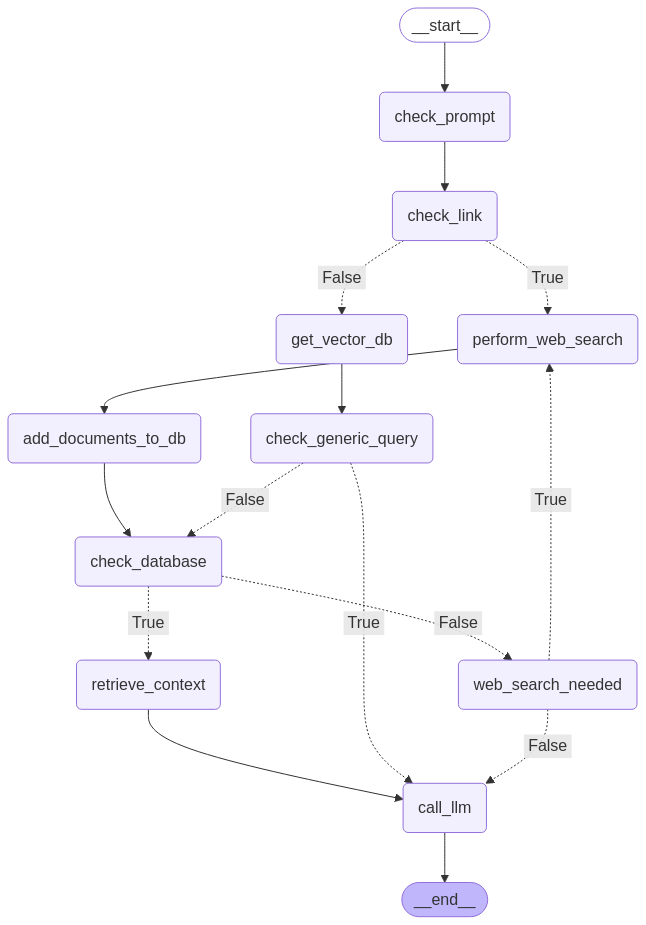

In [5]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except:
    pass

In [ ]:
#DB fetch
state = AgentState(prompt="Who is the current president of USA in 2025?")
res = await app.ainvoke(state)

Prompt received {'Who is the current president of USA in 2025?'}
Initializing agent state...
Is the prompt generic: {False}
page_content='US Presidents in 2025

He was then followed by Donald J. Trump, who is the 47th President, taking office on January 20, 2025. He is the current President of the United States.

Find the President in another year

United States Presidents' metadata={'source': 'https://whowaspresident.com/2025'}
Context exists in DB: {True}
Retrieved context: {"US Presidents in 2025\n\nHe was then followed by Donald J. Trump, who is the 47th President, taking office on January 20, 2025. He is the current President of the United States.\n\nFind the President in another year\n\nUnited States Presidents\n\nComplete List of Presidents of the US\n\nHere is the complete list of US Presidents till 2024: US President Name\n\nList of Presidents of USA: Donald Trump Takes the Office as 47th President\n\nCurrent GK Current GK Current GK\n\nPresident (R) was inaugurated for his se

In [5]:
# Direct LLM
state = AgentState(prompt="What is the capital of India?")
test = await app.ainvoke(state)

Prompt received {'What is the capital of India?'}
Initializing agent state...


Is the prompt generic: {True}
LLM Response: {'The capital of India is New Delhi.'}


In [7]:
#Web search
state = AgentState(prompt="Who is the current world chess champion?")
res = await app.ainvoke(state)

Prompt received {'Who is the current world chess champion?'}
Initializing agent state...
Is the prompt generic: {False}
Context exists in DB: {False}
Does the prompt needs to be web searched: {False}
[INIT].... → Crawl4AI 0.5.0.post4
[FETCH]... ↓ https://en.wikipedia.org/wiki/World_Chess_Champion... | Status: True | Time: 2.08s
[SCRAPE].. ◆ https://en.wikipedia.org/wiki/World_Chess_Champion... | Time: 0.593s
[COMPLETE] ● https://en.wikipedia.org/wiki/World_Chess_Champion... | Status: True | Total: 2.68s
[FETCH]... ↓ https://khelnow.com/chess/fide-world-chess-champio... | Status: True | Time: 3.74s
[SCRAPE].. ◆ https://khelnow.com/chess/fide-world-chess-champio... | Time: 0.069s
[COMPLETE] ● https://khelnow.com/chess/fide-world-chess-champio... | Status: True | Total: 3.81s
[FETCH]... ↓ https://en.wikipedia.org/wiki/Magnus_Carlsen... | Status: True | Time: 2.12s
[SCRAPE].. ◆ https://en.wikipedia.org/wiki/Magnus_Carlsen... | Time: 1.474s
[COMPLETE] ● https://en.wikipedia.org/wiki/Magnus_

In [8]:
#DB
state = AgentState(prompt="Who is the current world chess champion?")
res = await app.ainvoke(state)

Prompt received {'Who is the current world chess champion?'}
Initializing agent state...
Is the prompt generic: {False}
page_content='Competition to determine the World Champion in chess of India, the current world champion (2024) The World Chess Championship is played to determine the world champion in . The current world champion is , who defeated the previous champion in the . The first event recognized as a world championship was the between and . Steinitz won, making him the first world champion' metadata={'source': 'https://en.wikipedia.org/wiki/World_Chess_Championship'}
Context exists in DB: {True}
Retrieved context: {'Competition to determine the World Champion in chess of India, the current world champion (2024) The World Chess Championship is played to determine the world champion in . The current world champion is , who defeated the previous champion in the . The first event recognized as a world championship was the between and . Steinitz won, making him the first world ch

In [ ]:
#Generic link
#Web search - Edge case
state = AgentState(prompt="What is the domain and the organization for the link: https://www.tntra.io/?", web_search_count=0)
res = await app.ainvoke(state)

Prompt received {'What is the domain and the organization for the link: https://www.tntra.io/?'}
Initializing agent state...
Is the prompt generic: {False}
Context exists in DB: {False}
Does the prompt needs to be web searched: {False}
[INIT].... → Crawl4AI 0.5.0.post4
Web search documents: []
Documents added to DB
Context exists in DB: {False}
Does the prompt needs to be web searched: {False}
[INIT].... → Crawl4AI 0.5.0.post4
Web search documents: []
Documents added to DB
Context exists in DB: {True}
Retrieved context: {None}
LLM Response: {'The URL provided is "https://www.tntra.io/". \n\n- **Domain**: The main domain is "tntra.io".\n- **Organization**: Based on the domain structure and TLD "io", which is commonly used by tech companies, it suggests that "Tntra" likely refers to a technology-oriented organization. This could be a startup or a company involved in software development or a related field. Further research would involve checking WHOIS records or visiting the website for 